In [4]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from nilearn import plotting

sys.path.append("..")
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH

from utils import get_region_label

In [5]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

pos = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/SUBJ_0002_pos.csv').drop(columns='Unnamed: 0')
regions_meg = get_region_label(pos)


MEG Subject number :  32
iEEG Subject number :  30


[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

In [6]:
from utils import get_meg_data, get_ieeg_data, match_meg
ieeg_data_mean = get_ieeg_data(ieeg_datapath, ieeg_subj_list).mean(0)*1000 # As there is a /1000 in the normalisation function of the ieEG preproc -- To remove 
meg_data_source = get_meg_data(meg_outpath, meg_subj_list)
data_matched = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list).mean(0)

In [9]:
# PCA
pca= PCA(3)
pca.fit(ieeg_data_mean.T)
wieeg= pca.components_

pca.fit(data_matched.T)
wmeg= pca.components_

## compute labels

In [10]:
df = pd.DataFrame()

In [12]:
# Kmean clustering
labs = []
for W in [wieeg.T, wmeg.T] :
    cluster_range = range(2, 11)
    silhouette_scores = []
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k,random_state=0,n_init=10)
        labels = kmeans.fit_predict(W)
        score = silhouette_score(W, labels)
        silhouette_scores.append(score)
    optimal_k = cluster_range[np.argmax(silhouette_scores)]
    print("Number of clusters:", optimal_k)
    print("Best silhouette score:", max(silhouette_scores))
    final_model = KMeans(n_clusters=optimal_k,random_state=0,n_init=10)
    final_labels = final_model.fit_predict(W)
    labs.append(final_labels)  

df[f'ieeg'] = labs[0]
df[f'meg'] = labs[1]


Number of clusters: 6
Best silhouette score: 0.2162077109773264
Number of clusters: 10
Best silhouette score: 0.2637563781414702


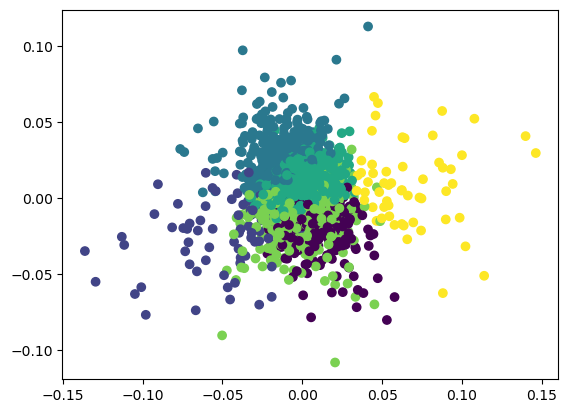

In [14]:
plt.scatter(wieeg[0, :], wieeg[1, :], c=df[f'ieeg'])

In [13]:
df.to_csv('out/labels_Kmean_allPC3.csv')

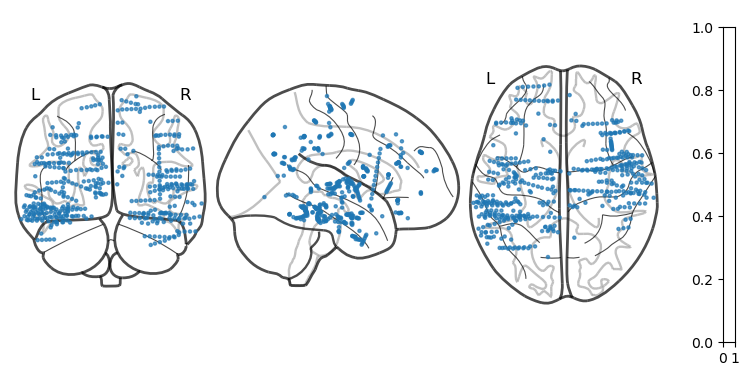

In [25]:
c=0
id_selected = np.where(df[f'meg_pc{c}'] == 0, True, False)
plotting.plot_markers(df[f'meg_pc{c}'].values[id_selected], coord[id_selected]*1000,node_cmap='tab10', node_size=5)

## Get lables

In [6]:
df = pd.read_csv('out/labels/labels_Kmean_singlePC3.csv')
df['regions']=regions_ieeg

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
metric_lab = pd.DataFrame()

for j in range(3) : 
    metric_lab.loc['ss_x', 'pc'+ str(j)] = silhouette_score(wieeg.T, df[f'ieeg_pc{j}'])
    metric_lab.loc['db_x', 'pc'+ str(j)] = davies_bouldin_score(wieeg.T, df[f'ieeg_pc{j}'])
    metric_lab.loc['ch_x', 'pc'+ str(j)] = calinski_harabasz_score(wieeg.T, df[f'ieeg_pc{j}'])

    metric_lab.loc['ss_y', 'pc'+ str(j)] = silhouette_score(wmeg.T, df[f'meg_pc{j}'])
    metric_lab.loc['db_y', 'pc'+ str(j)] = davies_bouldin_score(wmeg.T, df[f'meg_pc{j}'])
    metric_lab.loc['ch_y', 'pc'+ str(j)] = calinski_harabasz_score(wmeg.T, df[f'meg_pc{j}'])


metric_lab

,pc0,pc1,pc2
ss_x,0.223489,0.033645,0.134104
db_x,1.909191,3.278049,2.038129
ch_x,349.448412,171.752511,322.059273
ss_y,0.097311,0.157639,0.136516
db_y,2.705748,2.107131,2.239467
ch_y,303.516534,486.129676,430.811340


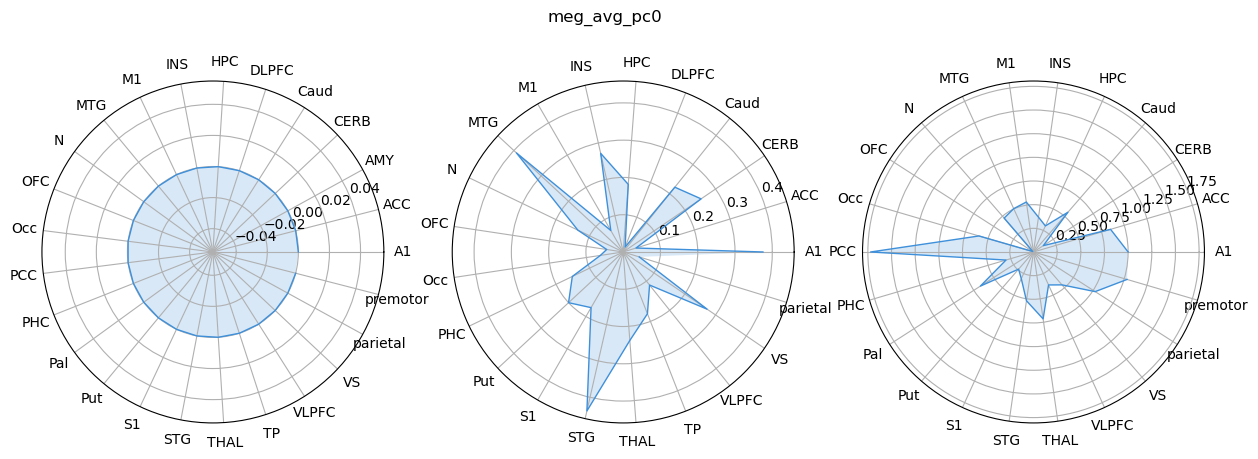

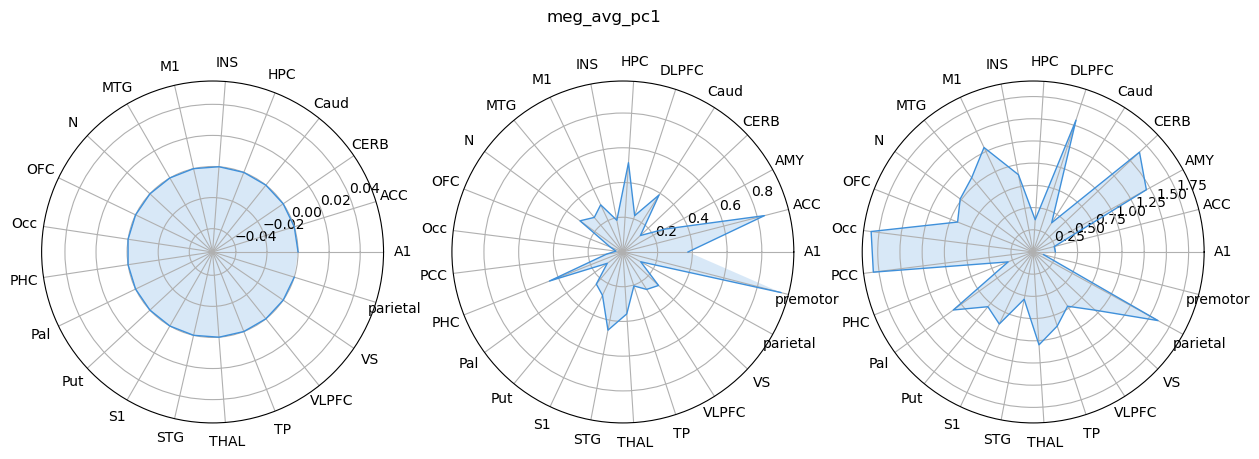

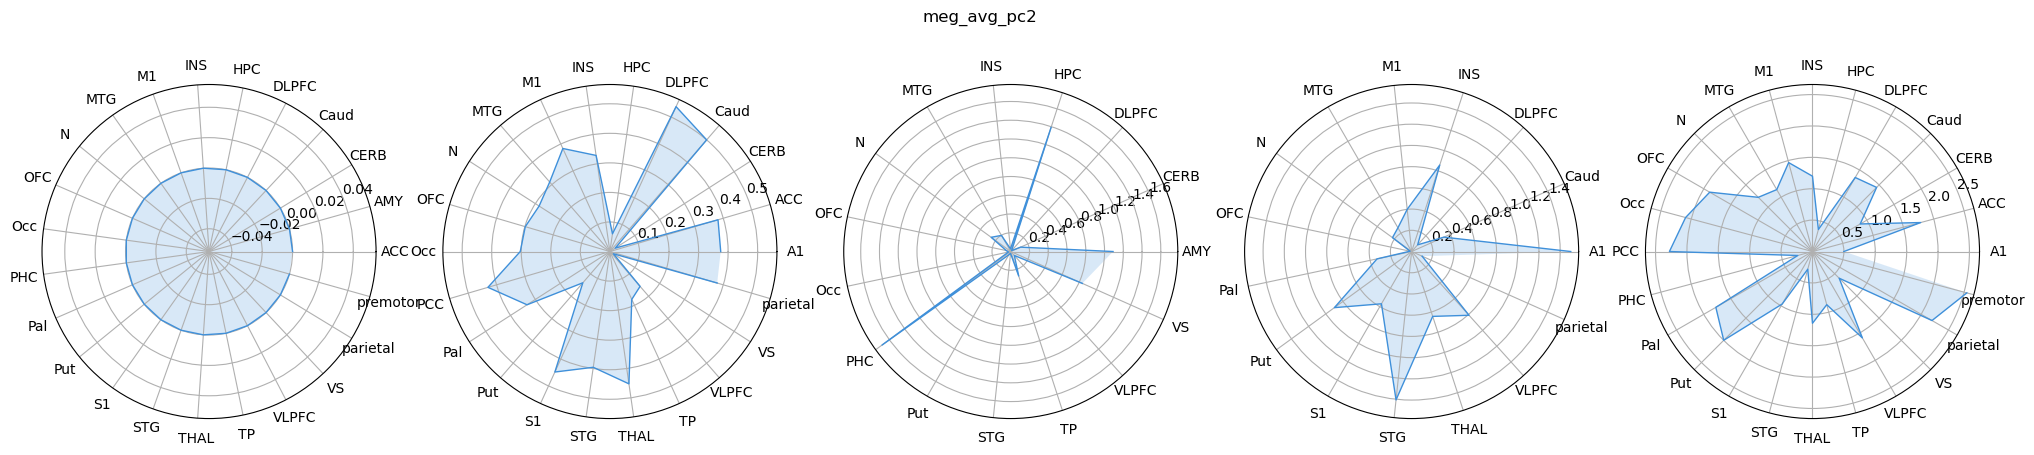

In [18]:
area_numbers= df.groupby('regions').count()['Unnamed: 0']

for nl in ['meg_avg_pc'] :#['ieeg_pc', 'meg_pc'] :
    for i in range(3) : 
        nameslabels = nl+str(i)
        fig, ax = plt.subplots(1, len(np.unique(df[nameslabels])), subplot_kw={"projection": "polar"}, figsize=(len(np.unique(df[nameslabels]))*5, 5))
        fig.suptitle(nameslabels)
        for l in np.unique(df[nameslabels]) :
            masked = np.where(df[nameslabels] == l, True, False )
            df_sub = df.loc[masked, : ].groupby('regions')[nameslabels].sum()
            df_sub= pd.merge(df_sub.reset_index(), area_numbers.reset_index(), on='regions')
            df_sub['mean'] = df_sub[nameslabels]/ df_sub['Unnamed: 0']

            angles = np.linspace(0, 2*np.pi, len(df_sub['mean']), endpoint=False)
            ax[l].plot(angles,df_sub['mean'].values,linewidth=1)
            ax[l].fill(angles,df_sub['mean'].values,alpha=0.2)
            ax[l].set_xticks(angles)
            ax[l].set_xticklabels(df_sub['regions'])


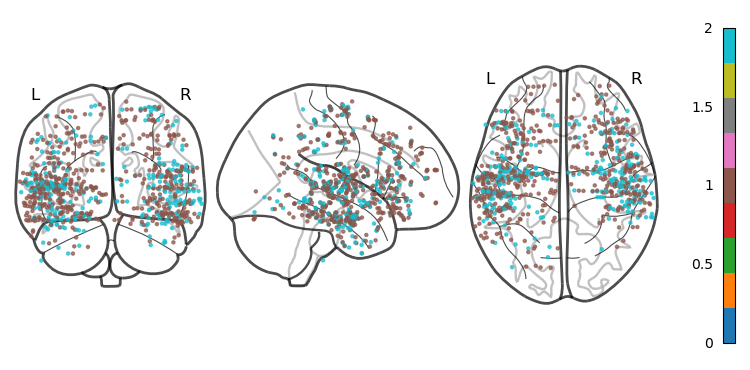

In [9]:
selected_reg = np.where(df['ieeg_pc0'] != 0, True, False)
size_node = np.where(df['ieeg_pc0'] != 0, np.ones((len(df)))*5, np.ones((len(df)))*0.0001)
plotting.plot_markers(df['ieeg_pc0'], coord*1000, node_size=size_node,node_cmap='tab10')

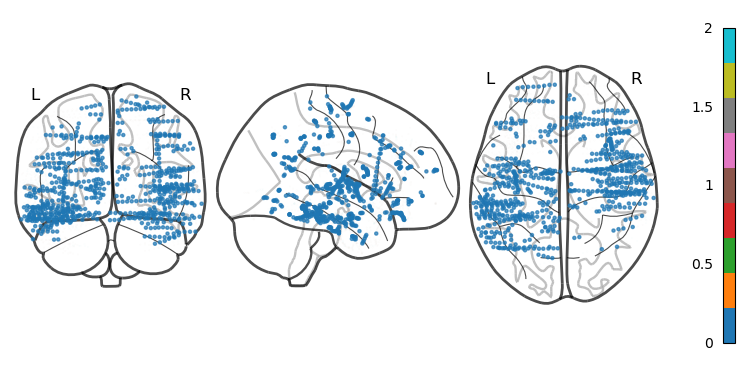

In [25]:
selected_reg = np.where(df['meg_pc0'] == 0, True, False)
size_node = np.where(df['meg_pc0'] == 0, np.ones((len(df)))*5, np.ones((len(df)))*0.0001)
plotting.plot_markers(df['meg_pc0'], coord*1000, node_size=size_node,node_cmap='tab10')

In [19]:
df

,Unnamed: 0,meg_avg_pc0,meg_avg_pc1,meg_avg_pc2,regions
0,0,2,0,0,VS
1,1,2,2,0,MTG
2,2,0,0,4,MTG
3,3,1,1,1,MTG
4,4,2,2,0,VS
...,...,...,...,...,...
3554,3554,2,0,4,STG
3555,3555,2,0,4,S1
3556,3556,2,0,4,S1
3557,3557,2,2,4,VLPFC


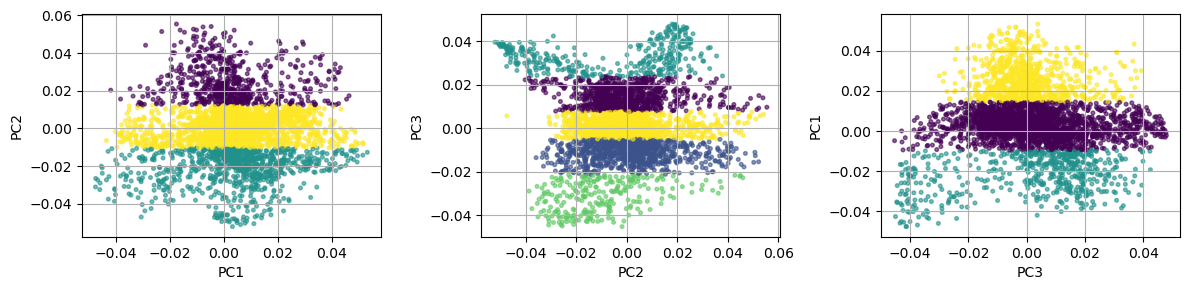

In [25]:
fig, ax=plt.subplots(1, 3, figsize=(12, 3))
for a in ax.flatten():
    a.grid()


for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[axi].scatter(wmeg[i, :], wmeg[j, :], s=7, alpha = 0.6, c=df[f'meg_avg_pc{j}']) # df_label[f'ieeg_pc{j}'].values np.array([COL_REG[r] for r in regions_ieeg])) #['pink']*ieeg_scaled.shape[0]) #
    ax[axi].set_ylabel(f'PC{j+1}')
    ax[axi].set_xlabel(f'PC{i+1}')

plt.tight_layout()
